## LinkedIn Job Salary Classification
### Notebook 2: Model Development

**Student:** Goudarz Javadizadeh  
**Student Number:** 25220901017  

This notebook loads the cleaned dataset produced by `data_prep` and trains, evaluates, and tunes three classification models plus a PyTorch MLP.

### Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
print('Libraries loaded.')

Libraries loaded.


### Load Cleaned Dataset
Produced by `data_prep` notebook.

In [3]:
df = pd.read_csv('linkedin_clean.csv')
print(f'Loaded {len(df)} rows')

# Restore feature matrix and target
features = ['work_type_enc', 'location_enc', 'exp_level_enc', 'views', 'applies', 'remote_allowed', 'sponsored']
X = df[features].copy()
y = df['high_salary'].copy()
median_salary = df['normalized_salary'].median()

print(f'Features: {features}')
print(f'Target distribution:\n{y.value_counts()}')

Loaded 32671 rows
Features: ['work_type_enc', 'location_enc', 'exp_level_enc', 'views', 'applies', 'remote_allowed', 'sponsored']
Target distribution:
high_salary
0    16360
1    16311
Name: count, dtype: int64


### Section 6: Train / Validation / Test Split and Scaling

I use a 70/15/15 split: 70% for training, 15% for validation (hyperparameter tuning), and 15% as a held-out test set that is never seen during model selection.

In [5]:
# Train / validation / test split (70 / 15 / 15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

print(f"Train size:      {X_train.shape[0]} rows")
print(f"Validation size: {X_val.shape[0]} rows")
print(f"Test size:       {X_test.shape[0]} rows")

# Scaling — fit on train only
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

print("\nStandardScaler fitted on training set only — no data leakage.")

Train size:      22869 rows
Validation size: 4901 rows
Test size:       4901 rows

StandardScaler fitted on training set only — no data leakage.


### Section 7: Model Training and Evaluation

### Helper Function
I define a reusable evaluation function to avoid repeating code for each model. It computes all required metrics and stores results for the final comparison table.

In [6]:
results = {}  # Store all model results for final comparison

def evaluate_model(name, model, X_tr, y_tr, X_v, y_v, use_scaled=True):
    """
    Train model, evaluate on validation set, store metrics.
    Returns fitted model and predicted probabilities.
    """
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_v)
    y_prob = model.predict_proba(X_v)[:, 1]

    acc  = accuracy_score(y_v, y_pred)
    prec = precision_score(y_v, y_pred)
    rec  = recall_score(y_v, y_pred)
    f1   = f1_score(y_v, y_pred)
    auc  = roc_auc_score(y_v, y_prob)

    results[name] = {
        'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC-AUC': auc
    }

    print(f"\n{'='*50}")
    print(f"  {name}")
    print(f"{'='*50}")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {auc:.4f}")

    return model, y_pred, y_prob

print("Evaluation helper function defined.")

Evaluation helper function defined.


### 7.1 Model 1: Logistic Regression

In [7]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr, lr_pred, lr_prob = evaluate_model(
    'Logistic Regression', lr,
    X_train_sc, y_train,
    X_val_sc, y_val
)


  Logistic Regression
  Accuracy:  0.6872
  Precision: 0.6881
  Recall:    0.6833
  F1-Score:  0.6857
  ROC-AUC:   0.7511


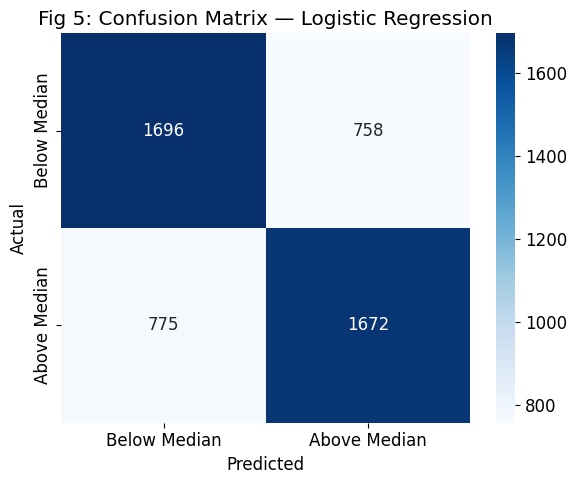

In [8]:
# Confusion Matrix — Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, lr_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Below Median', 'Above Median'],
            yticklabels=['Below Median', 'Above Median'])
ax.set_title('Fig 5: Confusion Matrix — Logistic Regression')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

### 7.2 Model 2: Decision Tree

In [9]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt, dt_pred, dt_prob = evaluate_model(
    'Decision Tree', dt,
    X_train_sc, y_train,
    X_val_sc, y_val
)


  Decision Tree
  Accuracy:  0.7172
  Precision: 0.7029
  Recall:    0.7511
  F1-Score:  0.7262
  ROC-AUC:   0.7933


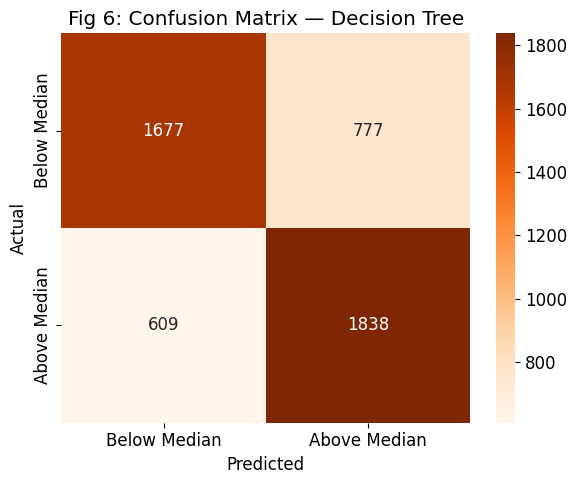

In [10]:
# Confusion Matrix — Decision Tree
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, dt_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', ax=ax,
            xticklabels=['Below Median', 'Above Median'],
            yticklabels=['Below Median', 'Above Median'])
ax.set_title('Fig 6: Confusion Matrix — Decision Tree')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

### 7.3 Model 3: Random Forest

In [11]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf, rf_pred, rf_prob = evaluate_model(
    'Random Forest', rf,
    X_train_sc, y_train,
    X_val_sc, y_val
)


  Random Forest
  Accuracy:  0.6941
  Precision: 0.6960
  Recall:    0.6878
  F1-Score:  0.6919
  ROC-AUC:   0.7562


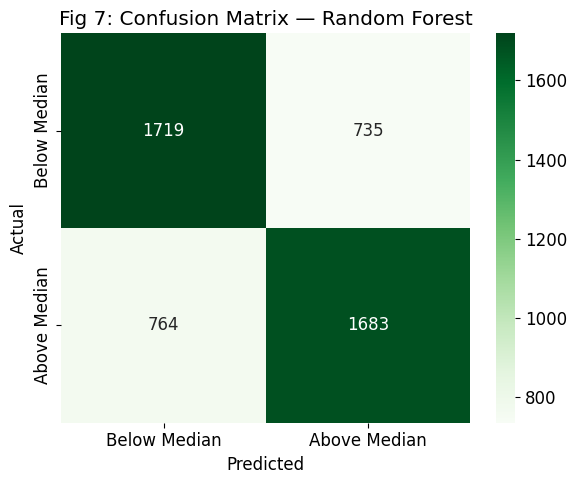

In [12]:
# Confusion Matrix — Random Forest
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, rf_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=ax,
            xticklabels=['Below Median', 'Above Median'],
            yticklabels=['Below Median', 'Above Median'])
ax.set_title('Fig 7: Confusion Matrix — Random Forest')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

### 7.4 Model 4: PyTorch MLP Classifier
A simple 3-layer feedforward neural network trained on the same features as the sklearn models.

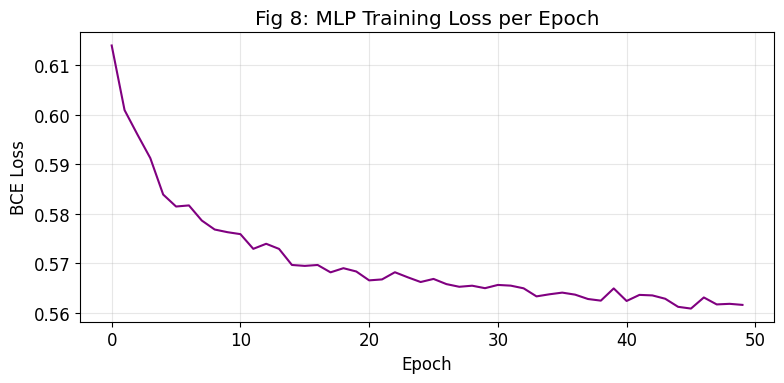

MLP — ROC-AUC: 0.7959  |  F1: 0.7250


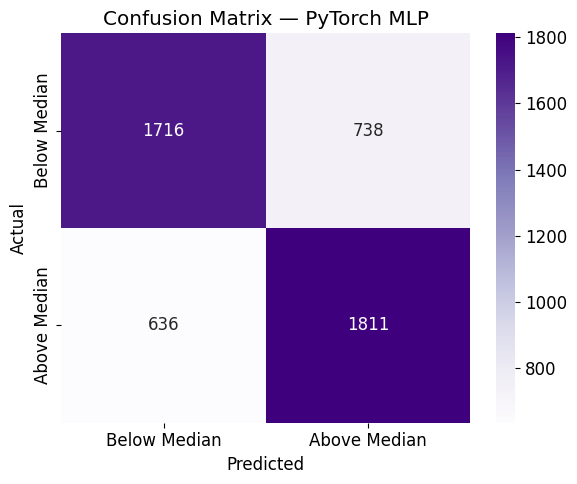

In [14]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Convert to tensors
X_tr_t  = torch.tensor(X_train_sc, dtype=torch.float32)
y_tr_t  = torch.tensor(y_train.values, dtype=torch.float32).unsqueeze(1)
X_val_t = torch.tensor(X_val_sc,   dtype=torch.float32)

# Dataset and loader
train_ds = TensorDataset(X_tr_t, y_tr_t)
train_dl = DataLoader(train_ds, batch_size=64, shuffle=True)

# Model definition
class SalaryMLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, 32),        nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(32, 1),         nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x)

model_mlp = SalaryMLP(X_train_sc.shape[1])
optimizer = torch.optim.Adam(model_mlp.parameters(), lr=0.001)
criterion = nn.BCELoss()

# Training loop
train_losses = []
for epoch in range(50):
    model_mlp.train()
    epoch_loss = 0
    for xb, yb in train_dl:
        optimizer.zero_grad()
        loss = criterion(model_mlp(xb), yb)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_losses.append(epoch_loss / len(train_dl))

# Training loss curve
plt.figure(figsize=(8, 4))
plt.plot(train_losses, color='purple')
plt.title('Fig 8: MLP Training Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Evaluation
model_mlp.eval()
with torch.no_grad():
    mlp_prob = model_mlp(X_val_t).squeeze().numpy()
    mlp_pred = (mlp_prob >= 0.5).astype(int)

mlp_auc = roc_auc_score(y_val, mlp_prob)
mlp_f1  = f1_score(y_val, mlp_pred)
print(f"MLP — ROC-AUC: {mlp_auc:.4f}  |  F1: {mlp_f1:.4f}")

# Confusion Matrix — MLP
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_val, mlp_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', ax=ax,
            xticklabels=['Below Median', 'Above Median'],
            yticklabels=['Below Median', 'Above Median'])
ax.set_title('Confusion Matrix — PyTorch MLP')
ax.set_ylabel('Actual')
ax.set_xlabel('Predicted')
plt.tight_layout()
plt.show()

### Section 8: ROC Curves — All Models

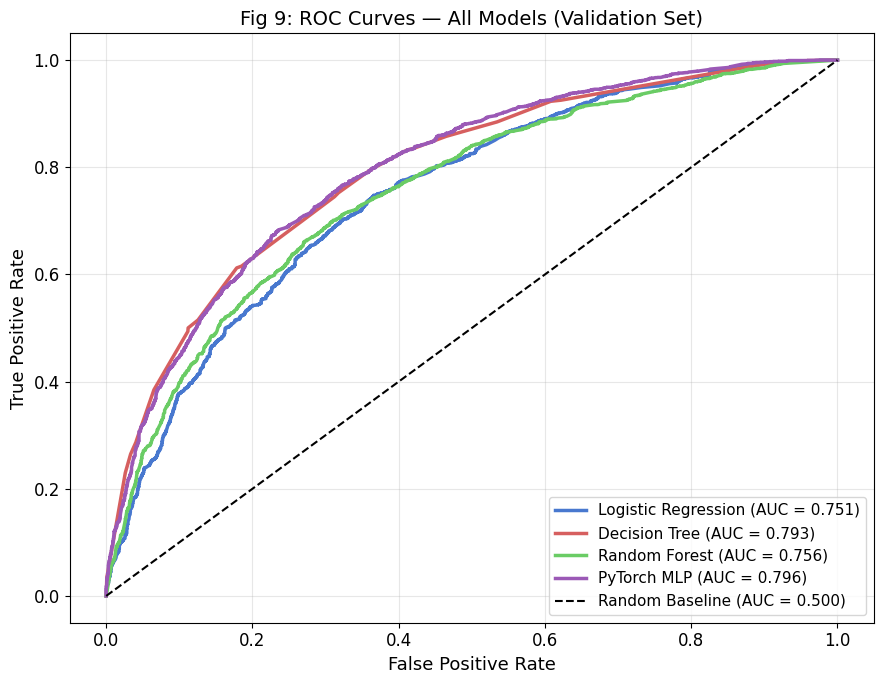

In [17]:
fig, ax = plt.subplots(figsize=(9, 7))

models_roc = [
    ('Logistic Regression', lr_prob,  '#4878cf'),
    ('Decision Tree',       dt_prob,  '#d65f5f'),
    ('Random Forest',       rf_prob,  '#6acc65'),
    ('PyTorch MLP',         mlp_prob, '#9b59b6'),
]

for name, prob, color in models_roc:
    fpr, tpr, _ = roc_curve(y_val, prob)
    auc = roc_auc_score(y_val, prob)
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline (AUC = 0.500)')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('Fig 9: ROC Curves — All Models (Validation Set)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Section 9: K-Fold Cross-Validation
I use 5-fold stratified cross-validation on the full training data, reporting mean and standard deviation of ROC-AUC across folds.

In [19]:
from sklearn.model_selection import StratifiedKFold
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = [
    ('Logistic Regression', LogisticRegression(max_iter=1000, random_state=42)),
    ('Decision Tree',       DecisionTreeClassifier(max_depth=5, random_state=42)),
    ('Random Forest',       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)),
]

print("5-Fold Cross-Validation Results (ROC-AUC on training data):\n")
for name, model in cv_models:
    scores = cross_val_score(model, X_train_sc, y_train, cv=skf, scoring='roc_auc', n_jobs=-1)
    print(f"  {name:<25} Mean AUC: {scores.mean():.4f}  ±  {scores.std():.4f}")

# PyTorch MLP — manual 5-fold CV (cross_val_score doesn't support PyTorch models)
mlp_aucs = []
X_tr_np = X_train_sc
y_tr_np = y_train.values

for fold, (train_idx, val_idx) in enumerate(skf.split(X_tr_np, y_tr_np)):
    xb = torch.tensor(X_tr_np[train_idx], dtype=torch.float32)
    yb = torch.tensor(y_tr_np[train_idx], dtype=torch.float32).unsqueeze(1)
    xv = torch.tensor(X_tr_np[val_idx],   dtype=torch.float32)
    yv = y_tr_np[val_idx]

    fold_ds = DataLoader(TensorDataset(xb, yb), batch_size=64, shuffle=True)
    fold_model = SalaryMLP(xb.shape[1])
    fold_opt   = torch.optim.Adam(fold_model.parameters(), lr=0.001)
    fold_loss  = nn.BCELoss()

    fold_model.train()
    for _ in range(30):
        for xbatch, ybatch in fold_ds:
            fold_opt.zero_grad()
            fold_loss(fold_model(xbatch), ybatch).backward()
            fold_opt.step()

    fold_model.eval()
    with torch.no_grad():
        preds = fold_model(xv).squeeze().numpy()
    mlp_aucs.append(roc_auc_score(yv, preds))

mlp_aucs = np.array(mlp_aucs)
print(f"  {'PyTorch MLP':<25} Mean AUC: {mlp_aucs.mean():.4f}  ±  {mlp_aucs.std():.4f}")

5-Fold Cross-Validation Results (ROC-AUC on training data):

  Logistic Regression       Mean AUC: 0.7412  ±  0.0071
  Decision Tree             Mean AUC: 0.7885  ±  0.0071
  Random Forest             Mean AUC: 0.7487  ±  0.0064
  PyTorch MLP               Mean AUC: 0.7857  ±  0.0073


---
## Section 10: Hyperparameter Tuning

I apply `GridSearchCV` on the validation set to find optimal hyperparameters for each model. Tuning is performed on the training data only. The best parameters are then used to retrain each model before final test evaluation.

In [20]:
# Logistic Regression tuning
print("Tuning Logistic Regression...")
lr_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs']
}
lr_grid = GridSearchCV(LogisticRegression(max_iter=1000, random_state=42),
                       lr_params, cv=5, scoring='roc_auc', n_jobs=-1)
lr_grid.fit(X_train_sc, y_train)
print(f"  Best params: {lr_grid.best_params_}")
print(f"  Best CV AUC: {lr_grid.best_score_:.4f}")

Tuning Logistic Regression...
  Best params: {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
  Best CV AUC: 0.7413


In [21]:
# Decision Tree tuning
print("Tuning Decision Tree...")
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 10, 20],
    'criterion': ['gini', 'entropy']
}
dt_grid = GridSearchCV(DecisionTreeClassifier(random_state=42),
                       dt_params, cv=5, scoring='roc_auc', n_jobs=-1)
dt_grid.fit(X_train_sc, y_train)
print(f"  Best params: {dt_grid.best_params_}")
print(f"  Best CV AUC: {dt_grid.best_score_:.4f}")

Tuning Decision Tree...
  Best params: {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 20}
  Best CV AUC: 0.7934


In [22]:
# Random Forest tuning
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

print("Tuning Random Forest...")
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 10]
}

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42), 
    param_grid=rf_params, 
    cv=5, 
    scoring='roc_auc', 
    n_jobs=-1
)

rf_grid.fit(X_train_sc, y_train)
print(f"  Best params: {rf_grid.best_params_}")
print(f"  Best CV AUC: {rf_grid.best_score_:.4f}")

Tuning Random Forest...
  Best params: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 100}
  Best CV AUC: 0.8011


In [23]:
# Hyperparameter Tuning — PyTorch MLP (manual grid search)
from itertools import product

lr_values         = [0.01, 0.001, 0.0001]
batch_size_values = [32, 64, 128]

best_auc    = 0
best_params = {}
tuning_results = []

for lr_val, bs_val in product(lr_values, batch_size_values):
    tune_ds = DataLoader(TensorDataset(X_tr_t, y_tr_t), batch_size=bs_val, shuffle=True)
    tune_model = SalaryMLP(X_train_sc.shape[1])
    tune_opt   = torch.optim.Adam(tune_model.parameters(), lr=lr_val)
    tune_loss  = nn.BCELoss()

    tune_model.train()
    for _ in range(30):
        for xbatch, ybatch in tune_ds:
            tune_opt.zero_grad()
            tune_loss(tune_model(xbatch), ybatch).backward()
            tune_opt.step()

    tune_model.eval()
    with torch.no_grad():
        val_preds = tune_model(X_val_t).squeeze().numpy()
    auc = roc_auc_score(y_val, val_preds)
    tuning_results.append({'lr': lr_val, 'batch_size': bs_val, 'AUC': round(auc, 4)})

    if auc > best_auc:
        best_auc    = auc
        best_params = {'lr': lr_val, 'batch_size': bs_val}

print("MLP Hyperparameter Tuning Results:")
print(pd.DataFrame(tuning_results).to_string(index=False))
print(f"\nBest params: {best_params}  |  Best AUC: {best_auc:.4f}")

MLP Hyperparameter Tuning Results:
    lr  batch_size    AUC
0.0100          32 0.7925
0.0100          64 0.7943
0.0100         128 0.8016
0.0010          32 0.7955
0.0010          64 0.7946
0.0010         128 0.7924
0.0001          32 0.7773
0.0001          64 0.7669
0.0001         128 0.7657

Best params: {'lr': 0.01, 'batch_size': 128}  |  Best AUC: 0.8016


---
## Section 11: Final Evaluation on Held-Out Test Set

The test set has been untouched until this point. I now evaluate the best version of each model (post-tuning) on the test set to report honest generalization performance.

In [24]:
# Retrain best MLP with tuned hyperparameters
best_ds = DataLoader(TensorDataset(X_tr_t, y_tr_t),
                     batch_size=best_params['batch_size'], shuffle=True)
best_mlp = SalaryMLP(X_train_sc.shape[1])
best_opt = torch.optim.Adam(best_mlp.parameters(), lr=best_params['lr'])
best_loss_fn = nn.BCELoss()

best_mlp.train()
for _ in range(50):
    for xbatch, ybatch in best_ds:
        best_opt.zero_grad()
        best_loss_fn(best_mlp(xbatch), ybatch).backward()
        best_opt.step()

X_te_t = torch.tensor(X_test_sc, dtype=torch.float32)

tuned_models = [
    ('Logistic Regression (Tuned)', lr_grid.best_estimator_),
    ('Decision Tree (Tuned)',       dt_grid.best_estimator_),
    ('Random Forest (Tuned)',       rf_grid.best_estimator_),
]

test_results = {}
test_probs   = {}

print("Final Test Set Performance (Tuned Models):\n")
for name, model in tuned_models:
    y_pred_test = model.predict(X_test_sc)
    y_prob_test = model.predict_proba(X_test_sc)[:, 1]

    test_results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred_test),
        'Precision': precision_score(y_test, y_pred_test),
        'Recall':    recall_score(y_test, y_pred_test),
        'F1':        f1_score(y_test, y_pred_test),
        'ROC-AUC':   roc_auc_score(y_test, y_prob_test)
    }
    test_probs[name] = y_prob_test

    print(f"  {name}")
    for k, v in test_results[name].items():
        print(f"    {k:<12}: {v:.4f}")
    print()

# Add MLP to test results
best_mlp.eval()
with torch.no_grad():
    mlp_prob_test = best_mlp(X_te_t).squeeze().numpy()
mlp_pred_test = (mlp_prob_test >= 0.5).astype(int)

test_results['PyTorch MLP (Tuned)'] = {
    'Accuracy':  accuracy_score(y_test, mlp_pred_test),
    'Precision': precision_score(y_test, mlp_pred_test),
    'Recall':    recall_score(y_test, mlp_pred_test),
    'F1':        f1_score(y_test, mlp_pred_test),
    'ROC-AUC':   roc_auc_score(y_test, mlp_prob_test)
}
test_probs['PyTorch MLP (Tuned)'] = mlp_prob_test

print(f"  PyTorch MLP (Tuned)")
for k, v in test_results['PyTorch MLP (Tuned)'].items():
    print(f"    {k:<12}: {v:.4f}")

Final Test Set Performance (Tuned Models):

  Logistic Regression (Tuned)
    Accuracy    : 0.6711
    Precision   : 0.6729
    Recall      : 0.6641
    F1          : 0.6684
    ROC-AUC     : 0.7349

  Decision Tree (Tuned)
    Accuracy    : 0.7135
    Precision   : 0.7331
    Recall      : 0.6702
    F1          : 0.7003
    ROC-AUC     : 0.7938

  Random Forest (Tuned)
    Accuracy    : 0.7260
    Precision   : 0.7233
    Recall      : 0.7307
    F1          : 0.7270
    ROC-AUC     : 0.7979

  PyTorch MLP (Tuned)
    Accuracy    : 0.7156
    Precision   : 0.6840
    Recall      : 0.7998
    F1          : 0.7374
    ROC-AUC     : 0.7879


In [25]:
# Table II: Final comparison table
comparison_df = pd.DataFrame(test_results).T.round(4)
print("TABLE II. FINAL MODEL COMPARISON (TEST SET)")
print(comparison_df.to_string())

TABLE II. FINAL MODEL COMPARISON (TEST SET)
                             Accuracy  Precision  Recall      F1  ROC-AUC
Logistic Regression (Tuned)    0.6711     0.6729  0.6641  0.6684   0.7349
Decision Tree (Tuned)          0.7135     0.7331  0.6702  0.7003   0.7938
Random Forest (Tuned)          0.7260     0.7233  0.7307  0.7270   0.7979
PyTorch MLP (Tuned)            0.7156     0.6840  0.7998  0.7374   0.7879


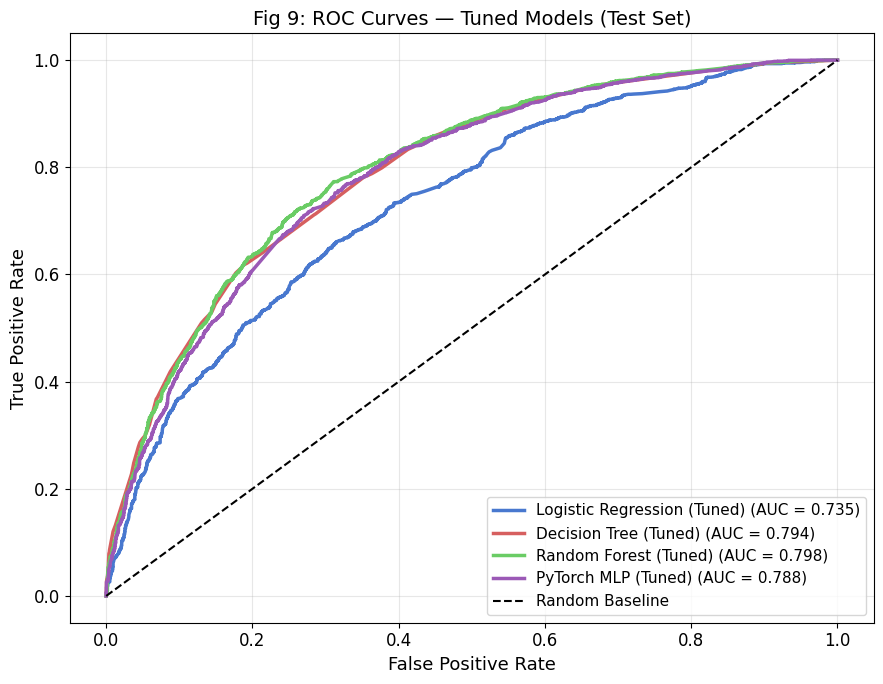

In [26]:
# Figure 9: ROC curves — tuned models on test set
fig, ax = plt.subplots(figsize=(9, 7))

all_test_models = [
    ('Logistic Regression (Tuned)', '#4878cf'),
    ('Decision Tree (Tuned)',       '#d65f5f'),
    ('Random Forest (Tuned)',       '#6acc65'),
    ('PyTorch MLP (Tuned)',         '#9b59b6'),
]

for name, color in all_test_models:
    fpr, tpr, _ = roc_curve(y_test, test_probs[name])
    auc = test_results[name]['ROC-AUC']
    ax.plot(fpr, tpr, color=color, linewidth=2.5, label=f'{name} (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random Baseline')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('Fig 9: ROC Curves — Tuned Models (Test Set)', fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Section 12: Deployment — Job Salary Classifier
Given a new job posting's attributes, predict whether it will pay above or below median salary.
Pipeline: Encode → Scale → Predict → Interpret

In [27]:
# Refit encoders from loaded data (defined in data_prep, not available here)
le_work = LabelEncoder().fit(df['formatted_work_type'].astype(str))
le_exp  = LabelEncoder().fit(df['formatted_experience_level'].astype(str))
location_target_mean = df.groupby('location')['high_salary'].mean()

# Define a new job posting
new_job = {
    'formatted_work_type': 'Full-time',
    'location': 'New York, NY',
    'formatted_experience_level': 'Mid-Senior level',
    'views': 500,
    'applies': 30,
    'remote_allowed': 1,
    'sponsored': 0
}

# Encode
work_enc = le_work.transform([new_job['formatted_work_type']])[0]
exp_enc  = le_exp.transform([new_job['formatted_experience_level']])[0]
loc_enc  = location_target_mean[new_job['location']] if new_job['location'] in location_target_mean.index else y.mean()

# Assemble and scale
new_X        = np.array([[work_enc, loc_enc, exp_enc,
                           new_job['views'], new_job['applies'],
                           new_job['remote_allowed'], new_job['sponsored']]])
new_X_scaled = scaler.transform(new_X)

# Predict with all tuned models
print("=== Deployment: Salary Class Prediction ===\n")
print(f"Median salary threshold: ${median_salary:,.0f}/year\n")

sklearn_models = [
    ('Logistic Regression', lr_grid.best_estimator_),
    ('Decision Tree',       dt_grid.best_estimator_),
    ('Random Forest',       rf_grid.best_estimator_),
]
for name, model in sklearn_models:
    pred = model.predict(new_X_scaled)[0]
    conf = model.predict_proba(new_X_scaled)[0][1]
    label = "ABOVE median" if pred == 1 else "BELOW median"
    print(f"  {name:<30} → {label}  (confidence: {conf:.2%})")

# MLP prediction
new_X_t = torch.tensor(new_X_scaled, dtype=torch.float32)
best_mlp.eval()
with torch.no_grad():
    mlp_conf = best_mlp(new_X_t).squeeze().item()
mlp_label = "ABOVE median" if mlp_conf >= 0.5 else "BELOW median"
print(f"  {'PyTorch MLP':<30} → {mlp_label}  (confidence: {mlp_conf:.2%})")

=== Deployment: Salary Class Prediction ===

Median salary threshold: $81,120/year

  Logistic Regression            → ABOVE median  (confidence: 76.48%)
  Decision Tree                  → ABOVE median  (confidence: 93.51%)
  Random Forest                  → ABOVE median  (confidence: 85.74%)
  PyTorch MLP                    → ABOVE median  (confidence: 58.04%)
